# Water Flow Tile Test

Extracts tiles from `jupyter/data/berlin.pmtiles`, converts MVT geometries to Shapely during extraction, and renders `water` polygons with `waterway` linestrings overlaid.

In [1]:
from __future__ import annotations

import gzip
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Iterable

from IPython.display import clear_output, display
from mapbox_vector_tile import decode
from matplotlib.colors import Normalize, TwoSlopeNorm
from PIL import Image, ImageDraw
from pmtiles.reader import Compression, MmapSource, Reader
from shapely.geometry import GeometryCollection, LineString, MultiLineString, MultiPolygon, Point, Polygon, shape
from shapely.geometry.base import BaseGeometry
from shapely.ops import unary_union
from shapely.prepared import prep

import ipywidgets as widgets
import numpy as np

In [2]:
%matplotlib widget
import matplotlib.pyplot as plt

In [3]:
DEFAULT_TILE = (14, 8798, 5373)
#DEFAULT_TILE = (11, 1099, 671)
#DEFAULT_TILE = (13, 4398, 2686)
DEFAULT_WATER_LAYER = "water"
DEFAULT_WATERWAY_LAYER = "waterway"
DEFAULT_IMAGE_SIZE = 512
DEFAULT_TILE_EXTENT = 4096
DEFAULT_FLOW_GRID_SIZE = 256
DEFAULT_FLOW_NEAREST_SEGMENT_COUNT = 4
DEFAULT_FLOW_SIGMA = DEFAULT_TILE_EXTENT / 32.0
DEFAULT_POISSON_ITERATIONS = 600
FLOW_EPSILON = 1e-9

In [4]:
def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "jupyter" / "data").is_dir():
            return candidate
    raise FileNotFoundError("Could not find repo root containing jupyter/data")


def default_pmtiles_path() -> Path:
    return find_repo_root() / "jupyter" / "data" / "berlin.pmtiles"


def extract_tile(pmtiles_path: Path, z: int, x: int, y: int) -> dict[str, Any]:
    with pmtiles_path.open("rb") as file:
        reader = Reader(MmapSource(file))
        header = reader.header()
        raw_tile = reader.get(z, x, y)

    if raw_tile is None:
        raise ValueError(f"Tile {z}/{x}/{y} was not found in {pmtiles_path}")

    tile_compression = (
        header["tile_compression"]
        if isinstance(header, dict)
        else header.tile_compression
    )
    tile_bytes = decompress_tile(raw_tile, tile_compression)
    decoded_tile = decode(
        tile_bytes,
        default_options={
            "geojson": False,
            "y_coord_down": True,
        },
    )
    return convert_tile_geometries_to_shapely(decoded_tile)


def decompress_tile(tile: bytes, compression: Compression) -> bytes:
    if compression == Compression.NONE:
        return tile
    if compression == Compression.GZIP:
        return gzip.decompress(tile)
    raise NotImplementedError(f"Unsupported PMTiles tile compression: {compression}")


def convert_tile_geometries_to_shapely(tile: dict[str, Any]) -> dict[str, Any]:
    converted_tile: dict[str, Any] = {}
    for layer_name, layer in tile.items():
        converted_features = []
        for feature in layer.get("features", []):
            geometry = feature.get("geometry")
            if geometry is None:
                continue
            converted_feature = dict(feature)
            converted_feature["geometry"] = shape(geometry)
            converted_features.append(converted_feature)

        converted_layer = dict(layer)
        converted_layer["features"] = converted_features
        converted_tile[layer_name] = converted_layer

    return converted_tile


def layer_summary(tile: dict[str, Any]) -> list[dict[str, Any]]:
    return [
        {
            "layer": name,
            "extent": layer.get("extent"),
            "features": len(layer.get("features", [])),
        }
        for name, layer in sorted(tile.items())
    ]

In [5]:
def extract_layer_geometries(
    tile: dict[str, Any],
    layer_name: str,
) -> tuple[list[BaseGeometry], int | None]:
    layer = tile.get(layer_name, {})
    geometries = [
        feature["geometry"]
        for feature in layer.get("features", [])
        if isinstance(feature.get("geometry"), BaseGeometry)
    ]
    return geometries, layer.get("extent")


def extract_water_geometries(
    tile: dict[str, Any],
    water_layer: str = DEFAULT_WATER_LAYER,
    waterway_layer: str = DEFAULT_WATERWAY_LAYER,
) -> tuple[list[BaseGeometry], list[BaseGeometry], int]:
    water_geometries, water_extent = extract_layer_geometries(tile, water_layer)
    waterway_geometries, waterway_extent = extract_layer_geometries(tile, waterway_layer)
    extent = int(water_extent or waterway_extent or DEFAULT_TILE_EXTENT)
    return water_geometries, waterway_geometries, extent

In [6]:
PMTILES_PATH = default_pmtiles_path()
TILE_Z, TILE_X, TILE_Y = DEFAULT_TILE

PMTILES_PATH, (TILE_Z, TILE_X, TILE_Y)

(WindowsPath('C:/Users/jonah/Documents/GitHub/sys-design-playground/jupyter/data/berlin.pmtiles'),
 (14, 8798, 5373))

In [7]:
tile = extract_tile(PMTILES_PATH, TILE_Z, TILE_X, TILE_Y)
water_geometries, waterway_geometries, tile_extent = extract_water_geometries(tile)
layer_summary(tile)

[{'layer': 'boundary', 'extent': 4096, 'features': 12},
 {'layer': 'building', 'extent': 4096, 'features': 1346},
 {'layer': 'housenumber', 'extent': 4096, 'features': 1033},
 {'layer': 'landcover', 'extent': 4096, 'features': 254},
 {'layer': 'landuse', 'extent': 4096, 'features': 133},
 {'layer': 'mountain_peak', 'extent': 4096, 'features': 1},
 {'layer': 'place', 'extent': 4096, 'features': 19},
 {'layer': 'poi', 'extent': 4096, 'features': 4875},
 {'layer': 'transportation', 'extent': 4096, 'features': 3112},
 {'layer': 'transportation_name', 'extent': 4096, 'features': 179},
 {'layer': 'water', 'extent': 4096, 'features': 18},
 {'layer': 'water_name', 'extent': 4096, 'features': 12},
 {'layer': 'waterway', 'extent': 4096, 'features': 11}]

In [8]:
print(f"water geometries: {len(water_geometries)}")
print(f"waterway geometries: {len(waterway_geometries)}")
print(f"extent: {tile_extent}")
print(f"first water geometry type: {water_geometries[0].geom_type if water_geometries else None}")
print(f"first waterway geometry type: {waterway_geometries[0].geom_type if waterway_geometries else None}")

water geometries: 18
waterway geometries: 11
extent: 4096
first water geometry type: Polygon
first waterway geometry type: LineString


In [9]:
def render_water_geometries(
    water_geometries: list[BaseGeometry],
    waterway_geometries: list[BaseGeometry],
    extent: int = DEFAULT_TILE_EXTENT,
    image_size: int = DEFAULT_IMAGE_SIZE,
    antialias_scale: int = 3,
) -> Image.Image:
    render_size = image_size * antialias_scale
    background = (250, 249, 245, 255)
    image = Image.new("RGBA", (render_size, render_size), background)
    draw = ImageDraw.Draw(image, "RGBA")

    for index, geometry in enumerate(water_geometries):
        fill = polygon_color(index)
        outline = darken(fill, 0.55)
        draw_polygon_geometry(
            draw,
            geometry,
            extent,
            render_size,
            fill,
            outline,
            background,
            width=max(1, antialias_scale),
        )

    for geometry in waterway_geometries:
        draw_line_geometry(
            draw,
            geometry,
            extent,
            render_size,
            fill=(255, 86, 51, 255),
            casing=(50, 44, 38, 220),
            width=max(2, antialias_scale * 2),
        )

    return image.resize((image_size, image_size), Image.Resampling.LANCZOS).convert("RGB")


def polygon_color(index: int) -> tuple[int, int, int, int]:
    rng = random.Random(10_000 + index)
    return (
        rng.randint(54, 110),
        rng.randint(130, 205),
        rng.randint(175, 235),
        185,
    )


def darken(color: tuple[int, int, int, int], factor: float) -> tuple[int, int, int, int]:
    return (
        int(color[0] * factor),
        int(color[1] * factor),
        int(color[2] * factor),
        255,
    )


def draw_polygon_geometry(
    draw: ImageDraw.ImageDraw,
    geometry: BaseGeometry,
    extent: int,
    image_size: int,
    fill: tuple[int, int, int, int],
    outline: tuple[int, int, int, int],
    background: tuple[int, int, int, int],
    width: int,
) -> None:
    for polygon in iter_polygons(geometry):
        exterior = [tile_to_pixel(point, extent, image_size) for point in polygon.exterior.coords]
        if len(exterior) >= 3:
            draw.polygon(exterior, fill=fill)
            draw.line([*exterior, exterior[0]], fill=outline, width=width)

        for interior in polygon.interiors:
            hole = [tile_to_pixel(point, extent, image_size) for point in interior.coords]
            if len(hole) >= 3:
                draw.polygon(hole, fill=background)
                draw.line([*hole, hole[0]], fill=outline, width=width)


def draw_line_geometry(
    draw: ImageDraw.ImageDraw,
    geometry: BaseGeometry,
    extent: int,
    image_size: int,
    fill: tuple[int, int, int, int],
    casing: tuple[int, int, int, int],
    width: int,
) -> None:
    for line in iter_lines(geometry):
        points = [tile_to_pixel(point, extent, image_size) for point in line.coords]
        if len(points) >= 2:
            draw.line(points, fill=casing, width=width + 2, joint="curve")
            draw.line(points, fill=fill, width=width, joint="curve")


def iter_polygons(geometry: BaseGeometry):
    if isinstance(geometry, Polygon):
        yield geometry
    elif isinstance(geometry, MultiPolygon):
        yield from geometry.geoms
    elif isinstance(geometry, GeometryCollection):
        for child in geometry.geoms:
            yield from iter_polygons(child)


def iter_lines(geometry: BaseGeometry):
    if isinstance(geometry, LineString):
        yield geometry
    elif isinstance(geometry, MultiLineString):
        yield from geometry.geoms
    elif isinstance(geometry, GeometryCollection):
        for child in geometry.geoms:
            yield from iter_lines(child)


def tile_to_pixel(point: tuple[float, float], extent: int, image_size: int) -> tuple[float, float]:
    return (
        point[0] / extent * image_size,
        point[1] / extent * image_size,
    )

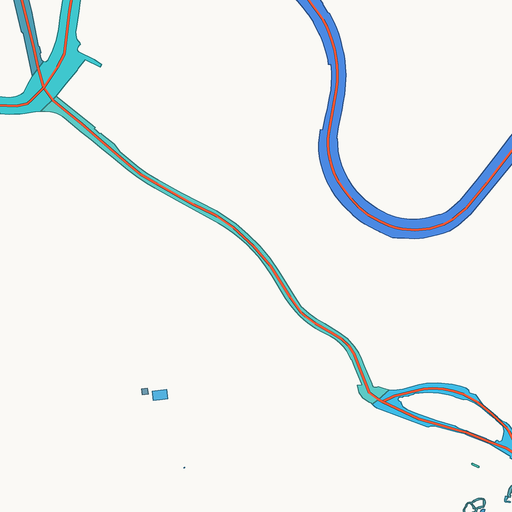

In [10]:
image = render_water_geometries(
    water_geometries,
    waterway_geometries,
    tile_extent,
    image_size=512,
)
display(image)

In [11]:
def merge_water_geometries(water_geometries: Iterable[BaseGeometry]) -> list[BaseGeometry]:
    valid_geometries = [geometry for geometry in water_geometries if not geometry.is_empty]
    if not valid_geometries:
        return []
    return [unary_union(valid_geometries)]


def merged_water_area(water_geometries: Iterable[BaseGeometry]) -> BaseGeometry:
    valid_geometries = [geometry for geometry in water_geometries if not geometry.is_empty]
    return unary_union(valid_geometries) if valid_geometries else GeometryCollection()

merged water geometries: 1
merged geometry type: MultiPolygon


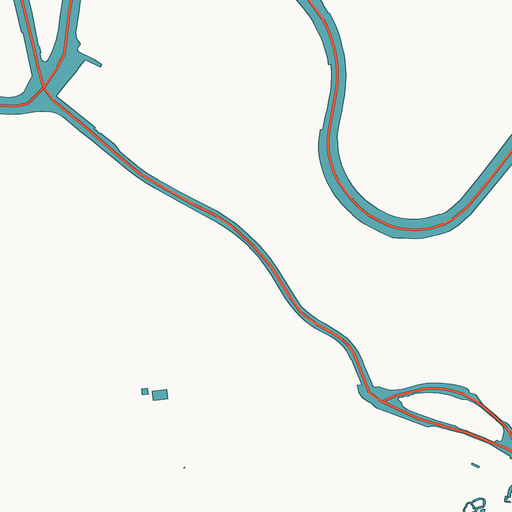

In [12]:
merged_water_geometries = merge_water_geometries(water_geometries)
print(f"merged water geometries: {len(merged_water_geometries)}")
print(f"merged geometry type: {merged_water_geometries[0].geom_type if merged_water_geometries else None}")

image = render_water_geometries(
    merged_water_geometries,
    waterway_geometries,
    tile_extent,
    image_size=512,
)
display(image)

Flow direction field:

- Split every waterway linestring into edge segments.
- Sample points inside the merged water geometry.
- For each point, take the nearest `N` water-contained segments.
- Weight each segment direction by `exp(-distance^2 / sigma^2) * confidence`.
- Normalize the weighted direction and visualize it with Matplotlib quiver arrows.

In [13]:
@dataclass(frozen=True)
class FlowSegment:
    a: tuple[float, float]
    b: tuple[float, float]
    line: LineString
    direction: np.ndarray
    confidence: float = 1.0


def extract_flow_segments(waterway_geometries: Iterable[BaseGeometry]) -> list[FlowSegment]:
    segments = []
    for geometry in waterway_geometries:
        for line in iter_lines(geometry):
            coords = list(line.coords)
            for a, b in zip(coords, coords[1:]):
                direction = np.array([b[0] - a[0], b[1] - a[1]], dtype=float)
                length = float(np.linalg.norm(direction))
                if length <= FLOW_EPSILON:
                    continue
                segments.append(
                    FlowSegment(
                        a=(float(a[0]), float(a[1])),
                        b=(float(b[0]), float(b[1])),
                        line=LineString([a, b]),
                        direction=direction / length,
                    )
                )
    return segments


def filter_segments_inside_water(
    segments: Iterable[FlowSegment],
    water_geometry: BaseGeometry,
) -> list[FlowSegment]:
    prepared_water = prep(water_geometry)
    return [
        segment
        for segment in segments
        if prepared_water.covers(Point(segment.a)) and prepared_water.covers(Point(segment.b))
    ]

In [14]:
@dataclass(frozen=True)
class BoundarySegment:
    a: tuple[float, float]
    b: tuple[float, float]
    line: LineString
    normal: np.ndarray


def iter_connected_water_geometries(geometry: BaseGeometry):
    if isinstance(geometry, Polygon):
        yield geometry
    elif isinstance(geometry, MultiPolygon):
        yield from geometry.geoms
    elif isinstance(geometry, GeometryCollection):
        for child in geometry.geoms:
            yield from iter_connected_water_geometries(child)


def rasterize_water_components(
    water_geometries: list[BaseGeometry],
    extent: int,
    grid_size: int,
) -> dict[str, Any]:
    water_geometry = merged_water_area(water_geometries)
    components = list(iter_connected_water_geometries(water_geometry))
    if not components and not water_geometry.is_empty:
        components = [water_geometry]

    prepared_components = [prep(component) for component in components]
    spacing = extent / grid_size
    sample_coords = np.linspace(spacing * 0.5, extent - spacing * 0.5, grid_size)
    x_grid, y_grid = np.meshgrid(sample_coords, sample_coords)
    component_ids = np.full((grid_size, grid_size), -1, dtype=int)
    water_mask = np.zeros_like(component_ids, dtype=bool)

    for row in range(grid_size):
        for column in range(grid_size):
            point = Point(float(x_grid[row, column]), float(y_grid[row, column]))
            for component_id, prepared_component in enumerate(prepared_components):
                if prepared_component.covers(point):
                    component_ids[row, column] = component_id
                    water_mask[row, column] = True
                    break

    solid_mask = ~water_mask
    boundary_mask = water_mask & (
        ~np.roll(water_mask, 1, axis=0)
        | ~np.roll(water_mask, -1, axis=0)
        | ~np.roll(water_mask, 1, axis=1)
        | ~np.roll(water_mask, -1, axis=1)
    )
    boundary_mask[0, :] |= water_mask[0, :]
    boundary_mask[-1, :] |= water_mask[-1, :]
    boundary_mask[:, 0] |= water_mask[:, 0]
    boundary_mask[:, -1] |= water_mask[:, -1]

    return {
        "water_geometry": water_geometry,
        "components": components,
        "prepared_components": prepared_components,
        "x": x_grid,
        "y": y_grid,
        "water_mask": water_mask,
        "solid_mask": solid_mask,
        "boundary_mask": boundary_mask,
        "correction_mask": water_mask & ~boundary_mask,
        "component_ids": component_ids,
        "spacing": spacing,
    }


def cell_component(component_ids: np.ndarray, row: int, column: int) -> int:
    if row < 0 or row >= component_ids.shape[0] or column < 0 or column >= component_ids.shape[1]:
        return -1
    return int(component_ids[row, column])


def component_for_point(point: tuple[float, float], prepared_components: list[Any]) -> int | None:
    shapely_point = Point(float(point[0]), float(point[1]))
    for component_id, prepared_component in enumerate(prepared_components):
        if prepared_component.covers(shapely_point):
            return component_id
    return None


def component_ids_for_segment(segment: FlowSegment, prepared_components: list[Any]) -> list[int]:
    midpoint = ((segment.a[0] + segment.b[0]) * 0.5, (segment.a[1] + segment.b[1]) * 0.5)
    ids = []
    for sample in (segment.a, segment.b, midpoint):
        component_id = component_for_point(sample, prepared_components)
        if component_id is not None and component_id not in ids:
            ids.append(component_id)
    return ids


def segments_by_component(
    segments: list[FlowSegment],
    prepared_components: list[Any],
) -> dict[int, list[FlowSegment]]:
    grouped = {component_id: [] for component_id in range(len(prepared_components))}
    for segment in segments:
        for component_id in component_ids_for_segment(segment, prepared_components):
            grouped[component_id].append(segment)
    return grouped


def extract_boundary_segments(water_geometry: BaseGeometry) -> list[BoundarySegment]:
    boundary_segments = []
    for polygon in iter_polygons(water_geometry):
        rings = [polygon.exterior, *polygon.interiors]
        for ring in rings:
            coords = list(ring.coords)
            for a, b in zip(coords, coords[1:]):
                direction = np.array([b[0] - a[0], b[1] - a[1]], dtype=float)
                length = float(np.linalg.norm(direction))
                if length <= FLOW_EPSILON:
                    continue
                normal = np.array([direction[1], -direction[0]], dtype=float) / length
                boundary_segments.append(
                    BoundarySegment(
                        a=(float(a[0]), float(a[1])),
                        b=(float(b[0]), float(b[1])),
                        line=LineString([a, b]),
                        normal=normal,
                    )
                )
    return boundary_segments


def closest_boundary_normal(point: tuple[float, float], boundary_segments: list[BoundarySegment]) -> np.ndarray:
    if not boundary_segments:
        return np.array([0.0, 1.0], dtype=float)
    shapely_point = Point(float(point[0]), float(point[1]))
    closest = min(boundary_segments, key=lambda segment: segment.line.distance(shapely_point))
    return closest.normal


def project_tangent(vector: np.ndarray, normal: np.ndarray) -> np.ndarray:
    normal_length = float(np.linalg.norm(normal))
    if normal_length <= FLOW_EPSILON:
        return vector
    unit_normal = normal / normal_length
    return vector - unit_normal * float(np.dot(vector, unit_normal))


def nearest_flow_vector_at_point(
    point: Point,
    segments: list[FlowSegment],
    sigma: float,
    nearest_count: int,
) -> tuple[np.ndarray, float, float] | None:
    if not segments:
        return None

    nearest = sorted(
        ((segment.line.distance(point), segment) for segment in segments),
        key=lambda item: item[0],
    )[:nearest_count]

    weighted_direction = np.zeros(2, dtype=float)
    weight_sum = 0.0
    for distance, segment in nearest:
        weight = float(np.exp(-(distance * distance) / (sigma * sigma))) * segment.confidence
        weighted_direction += weight * segment.direction
        weight_sum += weight

    if weight_sum <= FLOW_EPSILON:
        return None

    vector = weighted_direction / weight_sum
    magnitude = float(np.linalg.norm(vector))
    if magnitude <= FLOW_EPSILON:
        return None

    influence = min(weight_sum / max(1, len(nearest)), 1.0)
    return vector, magnitude, influence


def mac_face_component(component_ids: np.ndarray, row: int, column: int, axis: str) -> tuple[int | None, bool]:
    if axis == "u":
        first = cell_component(component_ids, row, column - 1)
        second = cell_component(component_ids, row, column)
    else:
        first = cell_component(component_ids, row - 1, column)
        second = cell_component(component_ids, row, column)

    if first >= 0 and second >= 0:
        if first == second:
            return first, False
        return None, False
    if first >= 0:
        return first, True
    if second >= 0:
        return second, True
    return None, False


def build_mac_faces(
    raster: dict[str, Any],
    component_segments: dict[int, list[FlowSegment]],
    boundary_segments: list[BoundarySegment],
    extent: int,
    grid_size: int,
    sigma: float,
    nearest_count: int,
) -> dict[str, np.ndarray]:
    spacing = raster["spacing"]
    component_ids = raster["component_ids"]
    u_faces = np.zeros((grid_size, grid_size + 1), dtype=float)
    v_faces = np.zeros((grid_size + 1, grid_size), dtype=float)
    u_boundary = np.zeros_like(u_faces, dtype=bool)
    v_boundary = np.zeros_like(v_faces, dtype=bool)

    for row in range(grid_size):
        y = (row + 0.5) * spacing
        for column in range(grid_size + 1):
            component_id, is_boundary = mac_face_component(component_ids, row, column, axis="u")
            if component_id is None:
                continue
            x = column * spacing
            flow = nearest_flow_vector_at_point(
                Point(float(x), float(y)),
                component_segments.get(component_id, []),
                sigma=sigma,
                nearest_count=nearest_count,
            )
            vector = flow[0] if flow is not None else np.zeros(2, dtype=float)
            if is_boundary:
                vector = project_tangent(vector, closest_boundary_normal((x, y), boundary_segments))
                u_boundary[row, column] = True
            u_faces[row, column] = vector[0]

    for row in range(grid_size + 1):
        y = row * spacing
        for column in range(grid_size):
            component_id, is_boundary = mac_face_component(component_ids, row, column, axis="v")
            if component_id is None:
                continue
            x = (column + 0.5) * spacing
            flow = nearest_flow_vector_at_point(
                Point(float(x), float(y)),
                component_segments.get(component_id, []),
                sigma=sigma,
                nearest_count=nearest_count,
            )
            vector = flow[0] if flow is not None else np.zeros(2, dtype=float)
            if is_boundary:
                vector = project_tangent(vector, closest_boundary_normal((x, y), boundary_segments))
                v_boundary[row, column] = True
            v_faces[row, column] = vector[1]

    return {
        "u_faces": u_faces,
        "v_faces": v_faces,
        "u_boundary": u_boundary,
        "v_boundary": v_boundary,
    }


def face_divergence(u_faces: np.ndarray, v_faces: np.ndarray, spacing: float) -> np.ndarray:
    return (u_faces[:, 1:] - u_faces[:, :-1] + v_faces[1:, :] - v_faces[:-1, :]) / spacing


def field_from_mac_faces(
    flow_field: dict[str, Any],
    u_faces: np.ndarray,
    v_faces: np.ndarray,
    title: str | None = None,
) -> dict[str, Any]:
    water_mask = flow_field["water_mask"]
    vector_u = 0.5 * (u_faces[:, :-1] + u_faces[:, 1:])
    vector_v = 0.5 * (v_faces[:-1, :] + v_faces[1:, :])
    magnitude = np.hypot(vector_u, vector_v)
    flow_mask = water_mask & np.isfinite(magnitude) & (magnitude > FLOW_EPSILON)

    direction_u = np.full_like(vector_u, np.nan, dtype=float)
    direction_v = np.full_like(vector_v, np.nan, dtype=float)
    direction_u[flow_mask] = vector_u[flow_mask] / magnitude[flow_mask]
    direction_v[flow_mask] = vector_v[flow_mask] / magnitude[flow_mask]

    coherence = np.zeros_like(magnitude, dtype=float)
    coherence[flow_mask] = np.minimum(magnitude[flow_mask], 1.0)

    influence = np.zeros_like(magnitude, dtype=float)
    max_magnitude = float(np.max(magnitude[flow_mask], initial=0.0))
    if max_magnitude > FLOW_EPSILON:
        influence[flow_mask] = np.clip(magnitude[flow_mask] / max_magnitude, 0.0, 1.0)

    updated = dict(flow_field)
    updated.update(
        {
            "u_faces": u_faces,
            "v_faces": v_faces,
            "vector_u": np.where(water_mask, vector_u, 0.0),
            "vector_v": np.where(water_mask, vector_v, 0.0),
            "u": direction_u,
            "v": direction_v,
            "coherence": coherence,
            "influence": influence,
            "flow_mask": flow_mask,
        }
    )
    if title is not None:
        updated["title"] = title
    return updated


def build_flow_field(
    water_geometries: list[BaseGeometry],
    waterway_geometries: list[BaseGeometry],
    extent: int = DEFAULT_TILE_EXTENT,
    grid_size: int = DEFAULT_FLOW_GRID_SIZE,
    sigma: float = DEFAULT_FLOW_SIGMA,
    nearest_count: int = DEFAULT_FLOW_NEAREST_SEGMENT_COUNT,
    require_segment_in_water: bool = True,
) -> dict[str, Any]:
    raster = rasterize_water_components(water_geometries, extent, grid_size)
    segments = extract_flow_segments(waterway_geometries)
    grouped_segments = segments_by_component(segments, raster["prepared_components"])
    if require_segment_in_water:
        used_segments = [segment for segments_in_component in grouped_segments.values() for segment in segments_in_component]
    else:
        grouped_segments = {
            component_id: segments
            for component_id in range(len(raster["prepared_components"]))
        }
        used_segments = segments

    boundary_segments = extract_boundary_segments(raster["water_geometry"])
    faces = build_mac_faces(
        raster,
        grouped_segments,
        boundary_segments,
        extent=extent,
        grid_size=grid_size,
        sigma=sigma,
        nearest_count=nearest_count,
    )

    flow_field = {
        **raster,
        **faces,
        "segments": segments,
        "used_segments": used_segments,
        "segments_by_component": grouped_segments,
        "boundary_segments": boundary_segments,
        "extent": extent,
        "grid_size": grid_size,
        "sigma": sigma,
        "nearest_count": nearest_count,
    }
    return field_from_mac_faces(flow_field, faces["u_faces"], faces["v_faces"])


In [15]:
def plot_polygon_geometry(
    ax,
    geometry: BaseGeometry,
    facecolor: str,
    edgecolor: str,
    alpha: float,
) -> None:
    for polygon in iter_polygons(geometry):
        x, y = polygon.exterior.xy
        ax.fill(x, y, facecolor=facecolor, edgecolor=edgecolor, alpha=alpha, linewidth=0.8)
        for interior in polygon.interiors:
            hole_x, hole_y = interior.xy
            ax.fill(hole_x, hole_y, facecolor="white", edgecolor=edgecolor, linewidth=0.5)


def plot_line_geometry(ax, geometry: BaseGeometry, color: str, linewidth: float) -> None:
    for line in iter_lines(geometry):
        x, y = line.xy
        ax.plot(x, y, color=color, linewidth=linewidth)


def default_flow_field_title(flow_field: dict[str, Any]) -> str:
    return (
        f"Waterway flow field: {len(flow_field['used_segments'])}/{len(flow_field['segments'])} segments, "
        f"N={flow_field['nearest_count']}, sigma={flow_field['sigma']:.0f}"
    )


def draw_flow_field(
    ax,
    water_geometries: list[BaseGeometry],
    waterway_geometries: list[BaseGeometry],
    flow_field: dict[str, Any],
    title: str | None = None,
    add_colorbar: bool = False,
):
    extent = flow_field["extent"]

    for index, geometry in enumerate(water_geometries):
        plot_polygon_geometry(
            ax,
            geometry,
            facecolor=f"C{index % 10}",
            edgecolor="#1f4f5f",
            alpha=0.24,
        )

    for geometry in waterway_geometries:
        plot_line_geometry(ax, geometry, color="#ff5533", linewidth=1.5)

    quiver = None
    mask = flow_field["flow_mask"]
    arrow_length = extent / flow_field["grid_size"] * 0.7
    if np.any(mask):
        quiver = ax.quiver(
            flow_field["x"][mask],
            flow_field["y"][mask],
            flow_field["u"][mask] * arrow_length * flow_field["coherence"][mask],
            flow_field["v"][mask] * arrow_length * flow_field["coherence"][mask],
            flow_field["influence"][mask],
            angles="xy",
            scale_units="xy",
            scale=1,
            cmap="viridis",
            width=0.0025,
            norm=Normalize(vmin=0.0, vmax=1.0),
        )
        if add_colorbar:
            ax.figure.colorbar(quiver, ax=ax, label="flow influence")

    ax.set_xlim(0, extent)
    ax.set_ylim(extent, 0)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title or flow_field.get("title", default_flow_field_title(flow_field)))
    ax.set_xlabel("tile x")
    ax.set_ylabel("tile y")
    return quiver


def plot_flow_field(
    water_geometries: list[BaseGeometry],
    waterway_geometries: list[BaseGeometry],
    flow_field: dict[str, Any],
    ax=None,
    add_colorbar: bool = True,
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    else:
        fig = ax.figure

    draw_flow_field(
        ax,
        water_geometries,
        waterway_geometries,
        flow_field,
        add_colorbar=add_colorbar,
    )
    return fig, ax


def plot_flow_field_comparison(
    water_geometries: list[BaseGeometry],
    waterway_geometries: list[BaseGeometry],
    base_flow_field: dict[str, Any],
    corrected_flow_field: dict[str, Any],
):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 7.5),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    quiver = draw_flow_field(
        axes[0],
        water_geometries,
        waterway_geometries,
        base_flow_field,
        title="Base flow field",
    )
    corrected_quiver = draw_flow_field(
        axes[1],
        water_geometries,
        waterway_geometries,
        corrected_flow_field,
        title="Poisson-corrected flow field",
    )
    axes[1].set_ylabel("")

    colorbar_source = corrected_quiver or quiver
    if colorbar_source is not None:
        fig.colorbar(
            colorbar_source,
            ax=axes.ravel().tolist(),
            label="flow influence",
            shrink=0.85,
        )

    return fig, axes

In [16]:
flow_field = build_flow_field(
    merged_water_geometries,
    waterway_geometries,
    extent=tile_extent,
    grid_size=DEFAULT_FLOW_GRID_SIZE,
    sigma=DEFAULT_FLOW_SIGMA,
    nearest_count=DEFAULT_FLOW_NEAREST_SEGMENT_COUNT,
    require_segment_in_water=True,
)

print(f"all waterway segments: {len(flow_field['segments'])}")
print(f"segments used for flow: {len(flow_field['used_segments'])}")
print(f"water sample points: {int(flow_field['water_mask'].sum())}")
print(f"boundary water sample points: {int(flow_field['boundary_mask'].sum())}")
print(f"correction sample points: {int(flow_field['correction_mask'].sum())}")
print(f"flow sample points: {int(flow_field['flow_mask'].sum())}")

all waterway segments: 102
segments used for flow: 103
water sample points: 4817
boundary water sample points: 1328
correction sample points: 3489
flow sample points: 4753


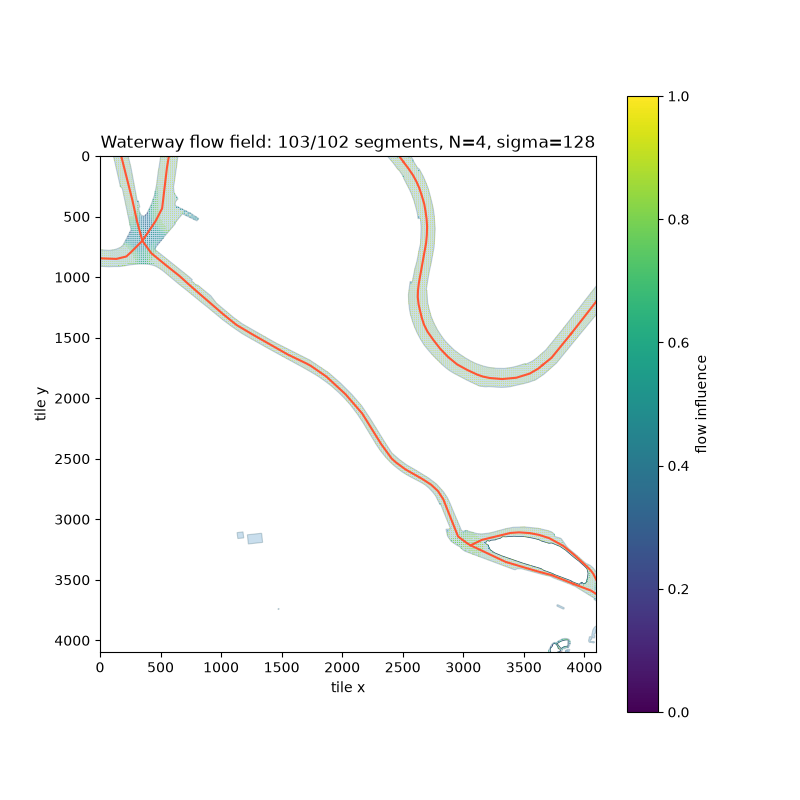

In [25]:
fig, ax = plot_flow_field(
    merged_water_geometries,
    waterway_geometries,
    flow_field,
)
plt.show()

In [18]:
def flow_grid_spacing(flow_field: dict[str, Any]) -> float:
    return float(flow_field["extent"]) / float(flow_field["grid_size"])


def flow_field_vector_components(flow_field: dict[str, Any]) -> tuple[np.ndarray, np.ndarray]:
    if "vector_u" in flow_field and "vector_v" in flow_field:
        return np.asarray(flow_field["vector_u"], dtype=float), np.asarray(flow_field["vector_v"], dtype=float)

    coherence = np.asarray(flow_field["coherence"], dtype=float)
    u = np.nan_to_num(np.asarray(flow_field["u"], dtype=float), nan=0.0) * coherence
    v = np.nan_to_num(np.asarray(flow_field["v"], dtype=float), nan=0.0) * coherence
    water_mask = np.asarray(flow_field["water_mask"], dtype=bool)
    return np.where(water_mask, u, 0.0), np.where(water_mask, v, 0.0)


def compute_flow_divergence(flow_field: dict[str, Any]) -> np.ndarray:
    divergence = face_divergence(
        np.asarray(flow_field["u_faces"], dtype=float),
        np.asarray(flow_field["v_faces"], dtype=float),
        flow_grid_spacing(flow_field),
    )
    return np.where(flow_field["water_mask"], divergence, np.nan)


def connected_component_labels(mask: np.ndarray) -> tuple[np.ndarray, int]:
    labels = np.full(mask.shape, -1, dtype=int)
    component_count = 0
    rows, columns = np.nonzero(mask)

    for start_row, start_column in zip(rows, columns):
        if labels[start_row, start_column] >= 0:
            continue

        stack = [(int(start_row), int(start_column))]
        labels[start_row, start_column] = component_count
        while stack:
            row, column = stack.pop()
            for next_row, next_column in (
                (row - 1, column),
                (row + 1, column),
                (row, column - 1),
                (row, column + 1),
            ):
                if (
                    0 <= next_row < mask.shape[0]
                    and 0 <= next_column < mask.shape[1]
                    and mask[next_row, next_column]
                    and labels[next_row, next_column] < 0
                ):
                    labels[next_row, next_column] = component_count
                    stack.append((next_row, next_column))

        component_count += 1

    return labels, component_count


def remove_component_mean(values: np.ndarray, labels: np.ndarray, component_count: int) -> np.ndarray:
    adjusted = np.array(values, dtype=float, copy=True)
    for component_id in range(component_count):
        component_mask = labels == component_id
        if np.any(component_mask):
            adjusted[component_mask] -= float(np.mean(adjusted[component_mask]))
    return adjusted


def solve_mac_poisson_potential(
    flow_field: dict[str, Any],
    divergence: np.ndarray,
    iterations: int = DEFAULT_POISSON_ITERATIONS,
    tolerance: float = 1e-5,
) -> np.ndarray:
    correction_mask = np.asarray(flow_field["correction_mask"], dtype=bool)
    component_ids = np.asarray(flow_field["component_ids"], dtype=int)
    spacing = flow_grid_spacing(flow_field)
    coefficient = 1.0 / (spacing * spacing)
    labels, component_count = connected_component_labels(correction_mask)
    rhs = np.where(correction_mask & np.isfinite(divergence), divergence, 0.0)
    rhs = remove_component_mean(rhs, labels, component_count)
    potential = np.zeros_like(rhs, dtype=float)
    rows, columns = np.nonzero(correction_mask)

    for _ in range(iterations):
        previous = potential.copy()
        next_potential = previous.copy()
        for row, column in zip(rows, columns):
            component_id = component_ids[row, column]
            weighted_sum = 0.0
            coefficient_sum = 0.0
            for next_row, next_column in (
                (row, column - 1),
                (row, column + 1),
                (row - 1, column),
                (row + 1, column),
            ):
                if (
                    0 <= next_row < correction_mask.shape[0]
                    and 0 <= next_column < correction_mask.shape[1]
                    and correction_mask[next_row, next_column]
                    and component_ids[next_row, next_column] == component_id
                ):
                    weighted_sum += previous[next_row, next_column] * coefficient
                    coefficient_sum += coefficient

            if coefficient_sum > 0.0:
                next_potential[row, column] = (weighted_sum - rhs[row, column]) / coefficient_sum

        potential = np.where(correction_mask, next_potential, 0.0)
        potential = remove_component_mean(potential, labels, component_count)
        if np.max(np.abs(potential - previous), initial=0.0) < tolerance:
            break

    return np.where(correction_mask, potential, np.nan)


def apply_mac_pressure_correction(
    flow_field: dict[str, Any],
    correction_potential: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    correction_mask = np.asarray(flow_field["correction_mask"], dtype=bool)
    component_ids = np.asarray(flow_field["component_ids"], dtype=int)
    spacing = flow_grid_spacing(flow_field)
    u_faces = np.array(flow_field["u_faces"], dtype=float, copy=True)
    v_faces = np.array(flow_field["v_faces"], dtype=float, copy=True)

    for row in range(flow_field["grid_size"]):
        for column in range(1, flow_field["grid_size"]):
            left = column - 1
            right = column
            if (
                correction_mask[row, left]
                and correction_mask[row, right]
                and component_ids[row, left] == component_ids[row, right]
            ):
                u_faces[row, column] -= (correction_potential[row, right] - correction_potential[row, left]) / spacing

    for row in range(1, flow_field["grid_size"]):
        for column in range(flow_field["grid_size"]):
            top = row - 1
            bottom = row
            if (
                correction_mask[top, column]
                and correction_mask[bottom, column]
                and component_ids[top, column] == component_ids[bottom, column]
            ):
                v_faces[row, column] -= (correction_potential[bottom, column] - correction_potential[top, column]) / spacing

    return u_faces, v_faces


def correct_flow_field(flow_field: dict[str, Any], correction_potential: np.ndarray) -> dict[str, Any]:
    u_faces, v_faces = apply_mac_pressure_correction(flow_field, correction_potential)
    corrected_field = field_from_mac_faces(
        flow_field,
        u_faces,
        v_faces,
        title="Poisson-corrected waterway flow field",
    )
    corrected_field["correction_potential"] = correction_potential
    return corrected_field


def poisson_correct_flow_field(
    flow_field: dict[str, Any],
    iterations: int = DEFAULT_POISSON_ITERATIONS,
    tolerance: float = 1e-5,
) -> tuple[dict[str, Any], np.ndarray, np.ndarray]:
    divergence = compute_flow_divergence(flow_field)
    correction_potential = solve_mac_poisson_potential(
        flow_field,
        divergence,
        iterations=iterations,
        tolerance=tolerance,
    )
    return correct_flow_field(flow_field, correction_potential), divergence, correction_potential


def finite_abs_mean(values: np.ndarray) -> float:
    finite_values = values[np.isfinite(values)]
    if finite_values.size == 0:
        return 0.0
    return float(np.mean(np.abs(finite_values)))


def zero_centered_norm(scalar_field: np.ndarray):
    finite_values = scalar_field[np.isfinite(scalar_field)]
    if finite_values.size == 0:
        return None

    limit = float(np.max(np.abs(finite_values), initial=0.0))
    if limit <= FLOW_EPSILON:
        limit = 1.0

    return TwoSlopeNorm(vmin=-limit, vcenter=0.0, vmax=limit)


def plot_polygon_outline(ax, geometry: BaseGeometry, color: str, linewidth: float, alpha: float = 1.0) -> None:
    for polygon in iter_polygons(geometry):
        x, y = polygon.exterior.xy
        ax.plot(x, y, color=color, linewidth=linewidth, alpha=alpha)
        for interior in polygon.interiors:
            hole_x, hole_y = interior.xy
            ax.plot(hole_x, hole_y, color=color, linewidth=max(0.5, linewidth * 0.75), alpha=alpha)


def plot_scalar_field(
    water_geometries: list[BaseGeometry],
    waterway_geometries: list[BaseGeometry],
    flow_field: dict[str, Any],
    scalar_field: np.ndarray,
    title: str,
    cmap: str = "coolwarm",
    colorbar_label: str = "value",
    center_zero: bool = False,
):
    extent = flow_field["extent"]
    fig, ax = plt.subplots(figsize=(8, 8))
    masked_scalar = np.ma.masked_invalid(scalar_field)
    norm = zero_centered_norm(scalar_field) if center_zero else None
    image = ax.imshow(
        masked_scalar,
        extent=(0, extent, extent, 0),
        origin="upper",
        interpolation="nearest",
        cmap=cmap,
        norm=norm,
    )

    for geometry in water_geometries:
        plot_polygon_outline(ax, geometry, color="#1f4f5f", linewidth=0.8, alpha=0.85)

    for geometry in waterway_geometries:
        plot_line_geometry(ax, geometry, color="#ff5533", linewidth=1.2)

    fig.colorbar(image, ax=ax, label=colorbar_label)
    ax.set_xlim(0, extent)
    ax.set_ylim(extent, 0)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.set_xlabel("tile x")
    ax.set_ylabel("tile y")
    return fig, ax


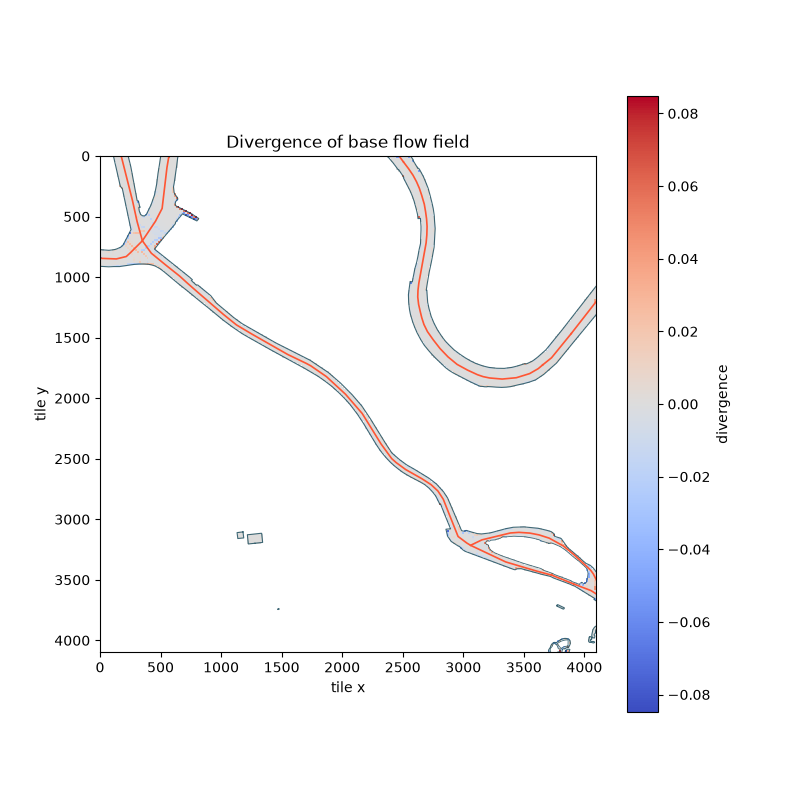

In [19]:
divergence_field = compute_flow_divergence(flow_field)
fig, ax = plot_scalar_field(
    merged_water_geometries,
    waterway_geometries,
    flow_field,
    divergence_field,
    title="Divergence of base flow field",
    cmap="coolwarm",
    colorbar_label="divergence",
    center_zero=True,
)
plt.show()

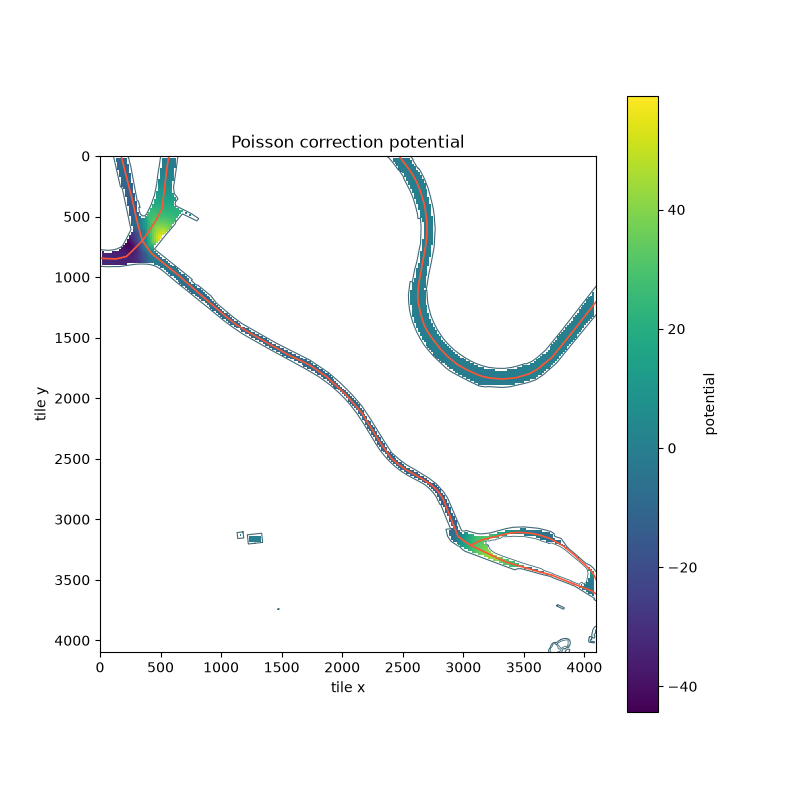

In [20]:
corrected_flow_field, divergence_field, correction_potential = poisson_correct_flow_field(flow_field)
fig, ax = plot_scalar_field(
    merged_water_geometries,
    waterway_geometries,
    flow_field,
    correction_potential,
    title="Poisson correction potential",
    cmap="viridis",
    colorbar_label="potential",
)
plt.show()

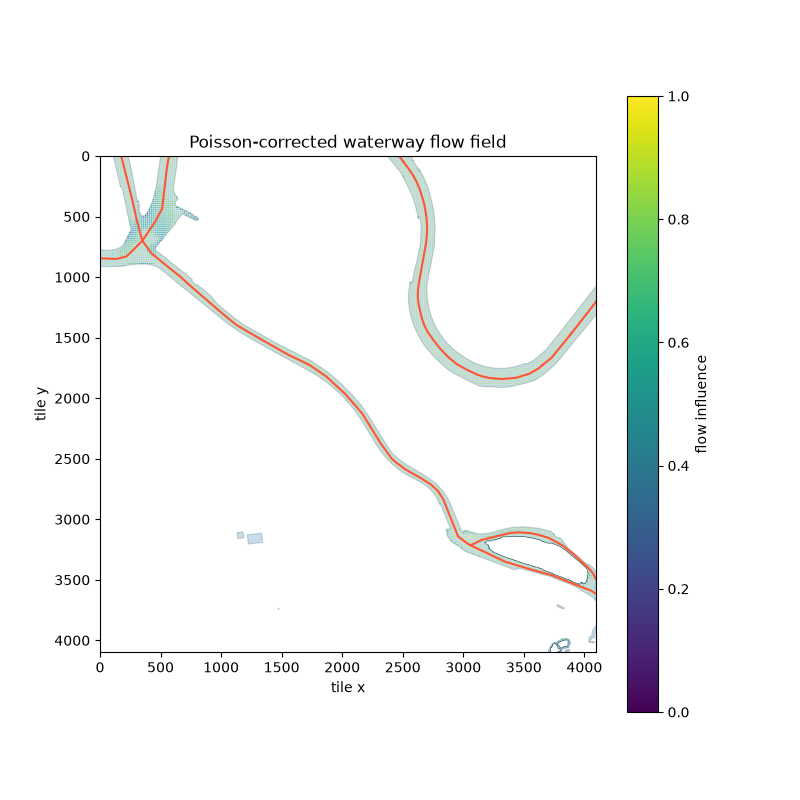

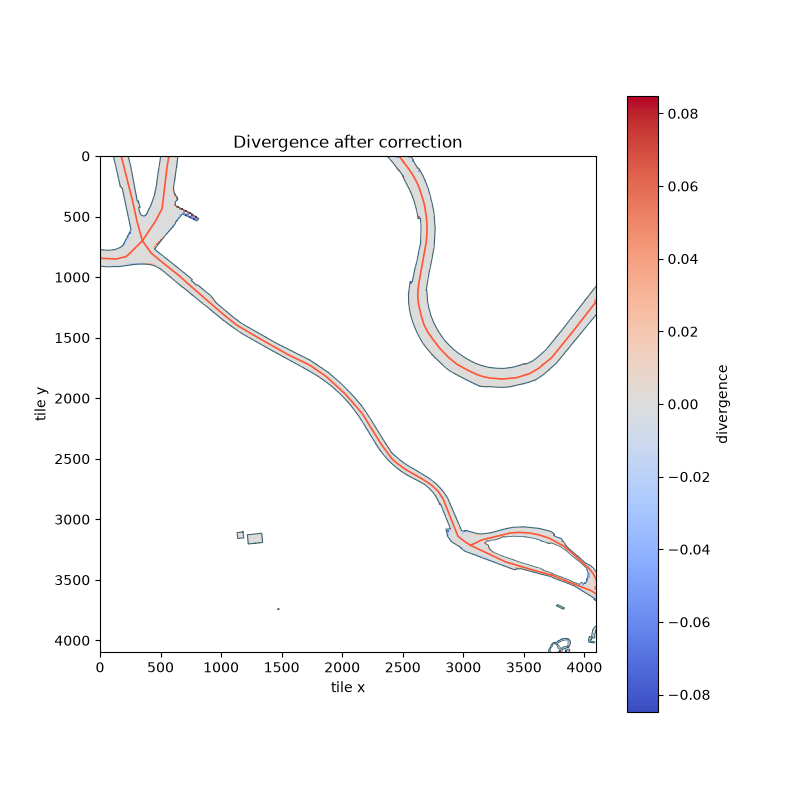

In [26]:
fig, ax = plot_flow_field(
    merged_water_geometries,
    waterway_geometries,
    corrected_flow_field,
)
plt.show()

corrected_divergence_field = compute_flow_divergence(corrected_flow_field)
fig, ax = plot_scalar_field(
    merged_water_geometries,
    waterway_geometries,
    corrected_flow_field,
    corrected_divergence_field,
    title="Divergence after correction",
    cmap="coolwarm",
    colorbar_label="divergence",
    center_zero=True,
)
plt.show()

Interactive flow comparison:

Use the sliders to rebuild the sampled vector field. The base and Poisson-corrected plots share axes, so pan and zoom stay synced in the widget figure.

In [22]:
grid_size_slider = widgets.IntSlider(
    value=DEFAULT_FLOW_GRID_SIZE,
    min=16,
    max=192,
    step=8,
    description="grid",
    continuous_update=False,
)
nearest_count_slider = widgets.IntSlider(
    value=DEFAULT_FLOW_NEAREST_SEGMENT_COUNT,
    min=1,
    max=12,
    step=1,
    description="nearest",
    continuous_update=False,
)
sigma_slider = widgets.FloatSlider(
    value=DEFAULT_FLOW_SIGMA,
    min=tile_extent / 128.0,
    max=tile_extent / 8.0,
    step=tile_extent / 128.0,
    description="sigma",
    readout_format=".0f",
    continuous_update=False,
)
contained_checkbox = widgets.Checkbox(
    value=True,
    description="contained segments",
    indent=False,
)


def update_interactive_flow(grid_size: int, nearest_count: int, sigma: float, contained_segments: bool):
    clear_output(wait=True)
    plt.close("all")

    updated_field = build_flow_field(
        merged_water_geometries,
        waterway_geometries,
        extent=tile_extent,
        grid_size=grid_size,
        sigma=sigma,
        nearest_count=nearest_count,
        require_segment_in_water=contained_segments,
    )
    corrected_field, divergence, _ = poisson_correct_flow_field(updated_field)
    corrected_divergence = compute_flow_divergence(corrected_field)

    print(f"all waterway segments: {len(updated_field['segments'])}")
    print(f"segments used for flow: {len(updated_field['used_segments'])}")
    print(f"water sample points: {int(updated_field['water_mask'].sum())}")
    print(f"boundary water sample points: {int(updated_field['boundary_mask'].sum())}")
    print(f"correction sample points: {int(updated_field['correction_mask'].sum())}")
    print(f"flow sample points: {int(updated_field['flow_mask'].sum())}")
    print(f"mean absolute divergence: {finite_abs_mean(divergence):.6f}")
    print(f"corrected mean absolute divergence: {finite_abs_mean(corrected_divergence):.6f}")

    fig, axes = plot_flow_field_comparison(
        merged_water_geometries,
        waterway_geometries,
        updated_field,
        corrected_field,
    )
    plt.show()


interactive_flow_output = widgets.interactive_output(
    update_interactive_flow,
    {
        "grid_size": grid_size_slider,
        "nearest_count": nearest_count_slider,
        "sigma": sigma_slider,
        "contained_segments": contained_checkbox,
    },
)

display(
    widgets.VBox(
        [
            widgets.HBox([grid_size_slider, nearest_count_slider]),
            widgets.HBox([sigma_slider, contained_checkbox]),
            interactive_flow_output,
        ]
    )
)

In [23]:
# u₀(x) = V₀ * d(x)

In [24]:
# ∇ · u = 0       inside water
# u · n = 0       at banks and island boundaries